# Crypto Volatility Prediction - Demo Notebook
This notebook demonstrates loading the sample dataset and running basic feature engineering.

### step 1 - src/data_loader.py testing

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_crypto_data

df = load_crypto_data("../data/raw/crypto.csv")
df.head()


,date,symbol,open,high,low,close,volume,market_cap
0,2023-01-01,BTC,20099.342831,20127.133047,19969.161691,19993.808167,1152302,20000000000
1,2023-01-02,BTC,20049.599148,20252.203412,19933.135410,19991.653921,947483,19993808166
2,2023-01-03,BTC,20040.026181,20423.448043,19694.352195,20140.451600,943771,19991653920
3,2023-01-04,BTC,20054.241190,20203.125247,19913.190927,20140.840386,786037,20140451599
4,2023-01-05,BTC,20154.441134,20441.591168,20044.723838,20285.838541,1011092,20140840385


### step 2 - DATA LOADING & CLEANING

In [3]:
from src.preprocessing import clean_data

df_clean = clean_data(df)
df_clean.head()


,date,symbol,open,high,low,close,volume,market_cap
0,2023-01-01,BTC,20099.342831,20127.133047,19969.161691,19993.808167,1152302,20000000000
1,2023-01-02,BTC,20049.599148,20252.203412,19933.135410,19991.653921,947483,19993808166
2,2023-01-03,BTC,20040.026181,20423.448043,19694.352195,20140.451600,943771,19991653920
3,2023-01-04,BTC,20054.241190,20203.125247,19913.190927,20140.840386,786037,20140451599
4,2023-01-05,BTC,20154.441134,20441.591168,20044.723838,20285.838541,1011092,20140840385


### step 3 - EDA (explolatory data analysis)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [5]:
# Basic information
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        400 non-null    datetime64[ns]
 1   symbol      400 non-null    object        
 2   open        400 non-null    float64       
 3   high        400 non-null    float64       
 4   low         400 non-null    float64       
 5   close       400 non-null    float64       
 6   volume      400 non-null    int64         
 7   market_cap  400 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 25.1+ KB


In [6]:
# Summary Statics
df_clean.describe()


,date,open,high,low,close,volume,market_cap
count,400,400.000000,400.000000,400.000000,400.000000,4.000000e+02,4.000000e+02
mean,2023-04-10 12:00:00,10419.688889,10503.092411,10330.916017,10411.248587,6.524343e+05,1.042035e+10
min,2023-01-01 00:00:00,1366.114110,1378.700797,1346.844141,1367.322038,7.864000e+03,1.367322e+09
25%,2023-02-19 18:00:00,1514.842130,1526.742749,1502.153551,1514.422893,3.013392e+05,1.514423e+09
50%,2023-04-10 12:00:00,8751.921063,8773.687220,8704.193428,8762.898442,6.934190e+05,8.762898e+09
75%,2023-05-30 06:00:00,19545.812117,19780.250870,19322.729086,19499.431744,1.003433e+06,1.950729e+10
max,2023-07-19 00:00:00,22645.048694,22708.165661,22221.814534,22582.802550,1.272016e+06,2.258280e+10
std,NaN,8995.752593,9068.964089,8917.705841,8987.578881,3.629595e+05,8.995439e+09


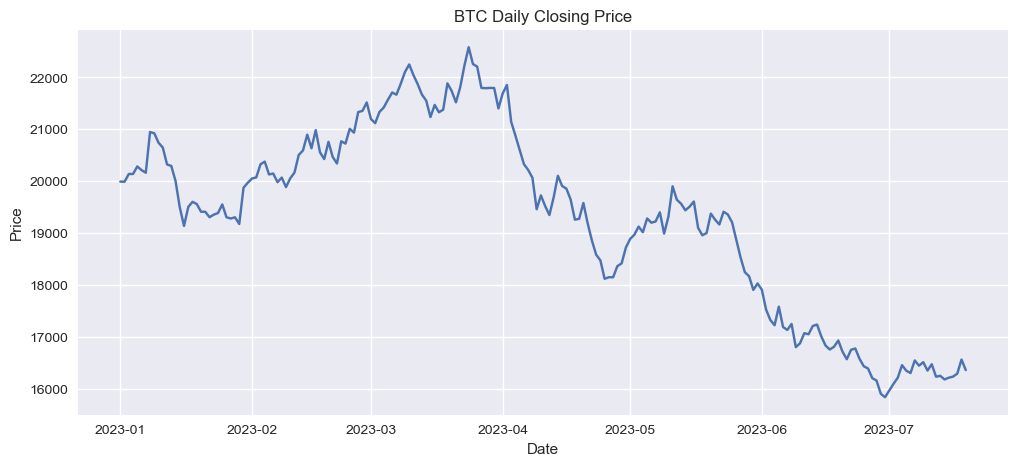

In [7]:
# BTC price trend plot 
btc = df_clean[df_clean["symbol"] == "BTC"]

plt.figure(figsize=(12,5))
plt.plot(btc["date"], btc["close"])
plt.title("BTC Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


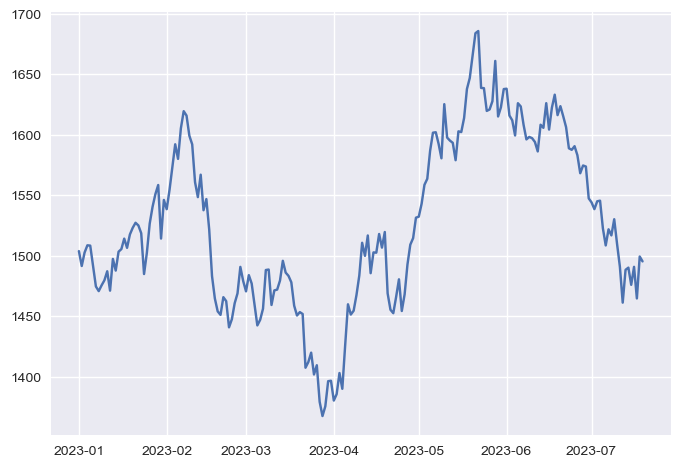

In [8]:
# ETH price trend plot 
eth = df_clean[df_clean["symbol"] == "ETH"]
plt.plot(eth["date"], eth["close"])


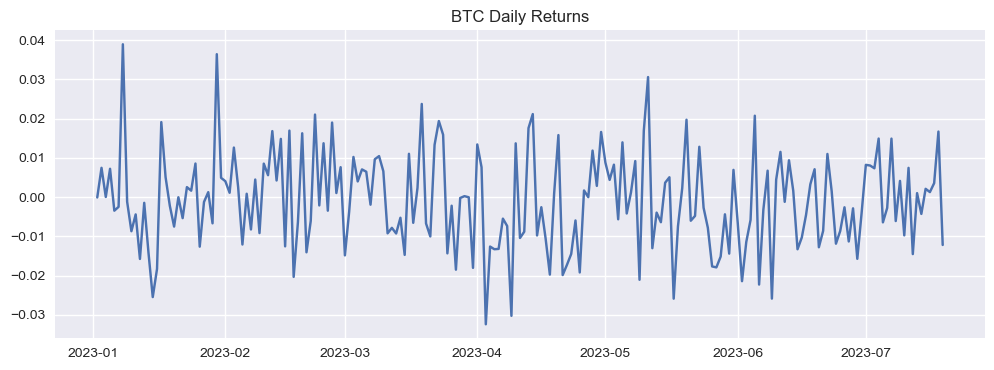

In [9]:
# Daily return plot
plt.figure(figsize=(12,4))
plt.plot(btc["date"], btc["close"].pct_change())
plt.title("BTC Daily Returns")
plt.show()


C:\Users\adars\AppData\Local\Temp\ipykernel_13560\3777346577.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc["rolling_vol"] = btc["close"].pct_change().rolling(14).std()


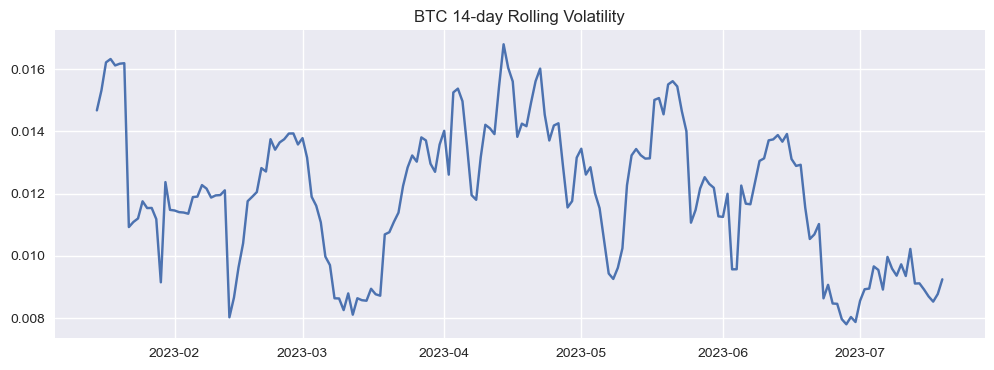

In [10]:
# Volatility plot (Rolling STD)
btc["rolling_vol"] = btc["close"].pct_change().rolling(14).std()

plt.figure(figsize=(12,4))
plt.plot(btc["date"], btc["rolling_vol"])
plt.title("BTC 14-day Rolling Volatility")
plt.show()


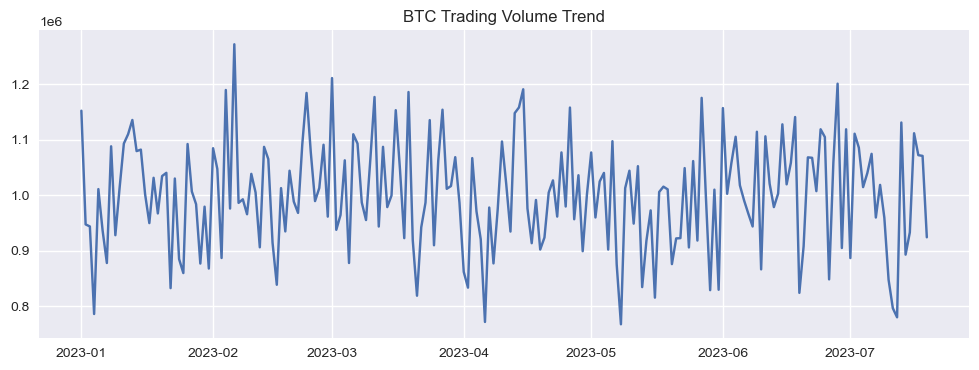

In [11]:
# Volume trends
plt.figure(figsize=(12,4))
plt.plot(btc["date"], btc["volume"])
plt.title("BTC Trading Volume Trend")
plt.show()


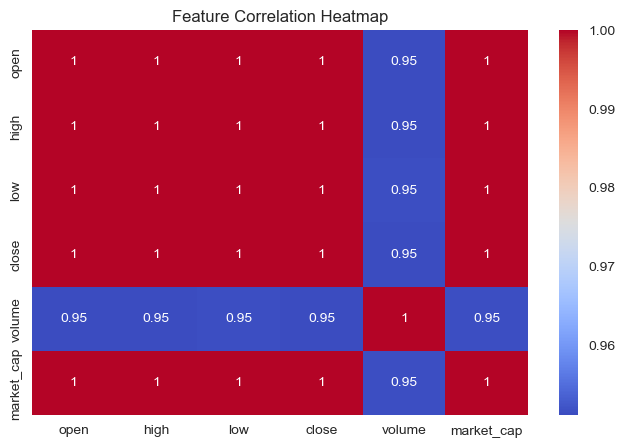

In [12]:
# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df_clean[["open","high","low","close","volume","market_cap"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


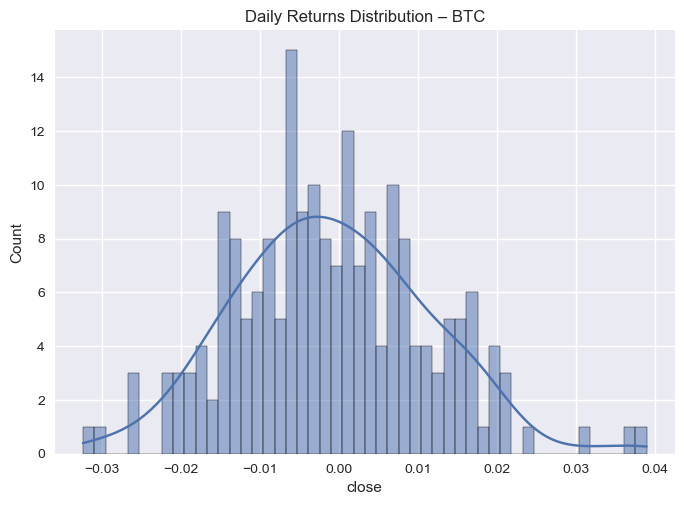

In [13]:
# Distributionn of returns 
sns.histplot(btc["close"].pct_change(), bins=50, kde=True)
plt.title("Daily Returns Distribution – BTC")
plt.show()


### step 4 - tesing feautures


In [14]:
from src.features import (
    add_returns, add_rolling_volatility, add_ATR,
    add_moving_averages, add_bollinger, add_liquidity
)

df_fe = df_clean.copy()

df_fe = add_returns(df_fe)
df_fe = add_rolling_volatility(df_fe)
df_fe = add_ATR(df_fe)
df_fe = add_moving_averages(df_fe)
df_fe = add_bollinger(df_fe)
df_fe = add_liquidity(df_fe)

df_fe.tail()


,date,symbol,open,high,low,close,volume,market_cap,return,rolling_vol,TR,ATR,ma_10,ma_30,ma_50,bb_mid,bb_upper,bb_lower,vol_mcap_ratio,rolling_vol_mean
395,2023-07-15,ETH,1473.735453,1479.067594,1447.152486,1475.878738,264501,1490098906,-0.009543,0.010863,42.946420,27.267559,1499.333042,1554.160452,1578.504470,1526.805475,1595.964181,1457.646770,0.000178,314517.785714
396,2023-07-16,ETH,1486.164940,1491.126049,1468.730373,1490.768013,336964,1475878738,0.010088,0.011422,22.395675,27.978184,1497.562952,1550.374799,1575.763365,1522.188671,1587.757865,1456.619477,0.000228,315492.285714
397,2023-07-17,ETH,1467.815157,1489.630956,1460.051032,1464.610631,96103,1490768012,-0.017546,0.011952,30.716981,29.050722,1491.841834,1545.111804,1571.832954,1517.008077,1583.627359,1450.388794,0.000064,306248.142857
398,2023-07-18,ETH,1489.985229,1523.231272,1480.478362,1499.308512,350084,1464610630,0.023691,0.014017,58.620641,32.866511,1490.095840,1540.649119,1569.515561,1513.242488,1574.443842,1452.041135,0.000239,323267.357143
399,2023-07-19,ETH,1483.364835,1496.320686,1464.652857,1495.257198,213496,1499308511,-0.002702,0.013535,34.655654,32.253017,1486.605984,1536.614509,1566.965627,1509.318320,1563.892458,1454.744182,0.000142,307893.357143


In [15]:
# remove NaN rows

df_fe = df_fe.dropna().reset_index(drop=True)
df_fe.head()


,date,symbol,open,high,low,close,volume,market_cap,return,rolling_vol,TR,ATR,ma_10,ma_30,ma_50,bb_mid,bb_upper,bb_lower,vol_mcap_ratio,rolling_vol_mean
0,2023-02-19,BTC,20706.575314,20878.184366,20703.439660,20759.874594,1044207,20428052003,0.016243,0.012047,450.132362,371.261265,20559.322982,20019.724359,20042.830012,20331.144764,20983.686870,19678.602658,0.000051,1.004574e+06
1,2023-02-20,BTC,20622.488554,20798.281520,20459.051055,20467.650799,988526,20759874593,-0.014076,0.012817,339.230465,370.780941,20600.413321,20054.889654,20052.306864,20355.909842,20988.404767,19723.414916,0.000048,9.843250e+05
2,2023-02-21,BTC,20309.677566,20647.082591,20241.793059,20343.213886,968215,20467650799,-0.006080,0.012706,405.289531,385.203481,20617.891924,20089.384943,20059.338064,20370.425534,20986.759148,19754.091919,0.000047,9.830352e+05
3,2023-02-22,BTC,20702.364018,20786.204806,20441.331232,20770.639034,1091786,20343213886,0.021011,0.013745,442.990920,399.937683,20644.235865,20136.500890,20071.941812,20405.220583,21029.786906,19780.654261,0.000054,9.901116e+05
4,2023-02-23,BTC,20849.005880,21193.296144,20572.374647,20726.196144,1184371,20770639034,-0.002140,0.013408,620.921497,418.276543,20657.484151,20181.090567,20083.648928,20425.142093,21064.546988,19785.737198,0.000057,1.005725e+06


In [16]:
# Saved processed data 
df_fe.to_csv("../data/processed/crypto_features.csv", index=False)


### step 5 - Model training

In [17]:
# import libaries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib


In [18]:
# load engineerred data set

df = pd.read_csv("../data/processed/crypto_features.csv", parse_dates=["date"])
df.head()


,date,symbol,open,high,low,close,volume,market_cap,return,rolling_vol,TR,ATR,ma_10,ma_30,ma_50,bb_mid,bb_upper,bb_lower,vol_mcap_ratio,rolling_vol_mean
0,2023-02-19,BTC,20706.575314,20878.184366,20703.439660,20759.874594,1044207,20428052003,0.016243,0.012047,450.132362,371.261265,20559.322982,20019.724359,20042.830012,20331.144764,20983.686870,19678.602658,0.000051,1.004574e+06
1,2023-02-20,BTC,20622.488554,20798.281520,20459.051055,20467.650799,988526,20759874593,-0.014076,0.012817,339.230465,370.780941,20600.413321,20054.889654,20052.306864,20355.909842,20988.404767,19723.414916,0.000048,9.843250e+05
2,2023-02-21,BTC,20309.677566,20647.082591,20241.793059,20343.213886,968215,20467650799,-0.006080,0.012706,405.289531,385.203481,20617.891924,20089.384943,20059.338064,20370.425534,20986.759148,19754.091919,0.000047,9.830352e+05
3,2023-02-22,BTC,20702.364018,20786.204806,20441.331232,20770.639034,1091786,20343213886,0.021011,0.013745,442.990920,399.937683,20644.235865,20136.500890,20071.941812,20405.220583,21029.786906,19780.654261,0.000054,9.901116e+05
4,2023-02-23,BTC,20849.005880,21193.296144,20572.374647,20726.196144,1184371,20770639034,-0.002140,0.013408,620.921497,418.276543,20657.484151,20181.090567,20083.648928,20425.142093,21064.546988,19785.737198,0.000057,1.005725e+06


In [19]:
# select target variable

y = df["rolling_vol"]


In [20]:
# select feature coloumns 
feature_cols = ["ATR", "ma_10", "ma_30", "bb_upper", "bb_lower", "vol_mcap_ratio"]
X = df[feature_cols]


In [21]:
# train-test split
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


In [22]:
# Train random forest model
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [23]:
# make predictions
y_pred = rf.predict(X_test)


In [24]:
# Evaluate model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)   # manually square root le lo
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)



RMSE: 0.002610991158159117
MAE: 0.002232325807332109
R2: -0.08491048444301774


In [41]:
# Save trained Model
import joblib
joblib.dump(rf, "rf_volatility_model.pkl")


['rf_volatility_model.pkl']

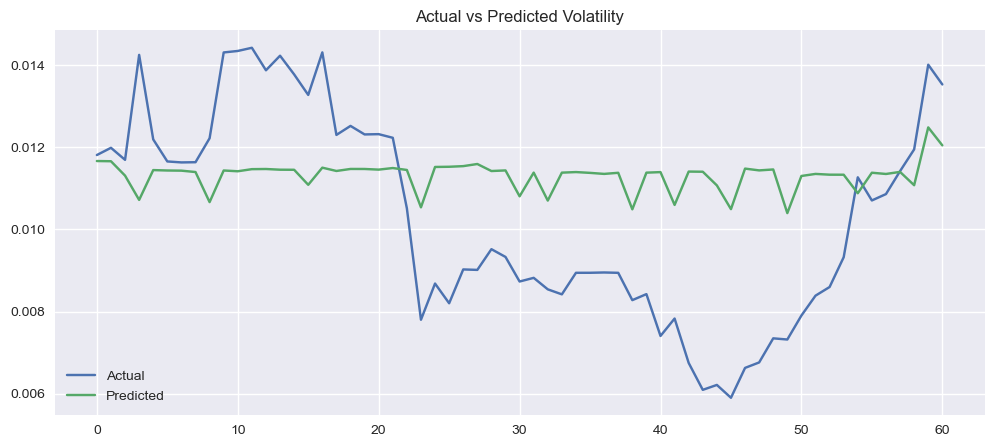

In [26]:
# Plot actual vs predicted
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Volatility")
plt.show()


### step 6 - Model testing & Inference

In [27]:
# load save data

import joblib

# Saved Random Forest model load karo
rf_model = joblib.load("../models/rf_volatility_model.pkl")


In [28]:
# prepare test /new data 
# Naye data ke liye same feature columns use karo
X_new = df[feature_cols]  # df_test ho sakta hai agar test dataset alag hai


In [29]:
# make prediction
# Model se predicted volatility nikal lo
y_new_pred = rf_model.predict(X_new)


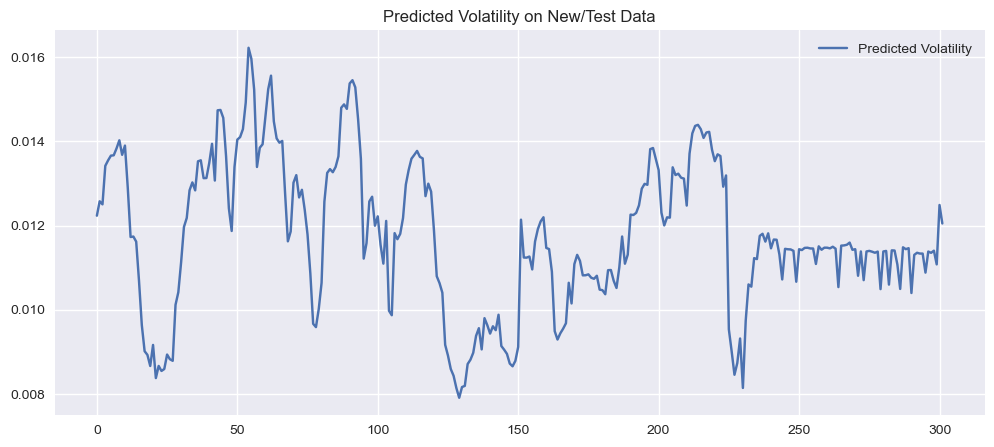

In [30]:
# visualize prediction

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_new_pred, label="Predicted Volatility")
plt.title("Predicted Volatility on New/Test Data")
plt.legend()
plt.show()


In [31]:
# interpreat prediction
print("High predicted volatility -> market zyada unstable hai")
print("Low predicted volatility -> market stable hai")


High predicted volatility -> market zyada unstable hai
Low predicted volatility -> market stable hai
